### CUAD Subword Tokenization and Chunking - Dzifa Thomas

This notebook prepares contract text for the transformer-based modeling approach.
1. Loads one row per contract from CUAD's official train/test split
2. Tokenizes and splits long contracts into manageable chunks
3. Preserves each chunk's location in the original contract for later label alignment
4. Explores contract token lengths and the number of chunks required

In [5]:
import json, re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load one row per contract

 In the flattened Q&A tables, each contract's full text is repeated for all 41 clause questions. For tokenization, I only need each contract's text once, so I will pull one row per contract (title + context) straight from the JSON.

In [6]:
with open('../data/train_separate_questions.json', 'r') as file:
    train_json = json.load(file)
with open('../data/test.json', 'r') as file:
    test_json = json.load(file)

In [8]:
def get_contracts(cuad_json):
    contracts = []
    for contract in cuad_json['data']:
        for paragraph in contract['paragraphs']:
            contracts.append({"title": contract['title'], "context": paragraph['context']})
    return pd.DataFrame(contracts)

In [9]:
train_contracts = get_contracts(train_json)
test_contracts = get_contracts(test_json)

In [10]:
train_contracts.shape

(408, 2)

In [11]:
test_contracts.shape

(102, 2)

In [12]:
train_contracts['title'].is_unique

True

In [13]:
test_contracts['title'].is_unique

True

In [14]:
train_contracts.head(5)

,title,context
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION A...",Exhibit 10.26 CONFIDENTIAL TREATMENT HAS BE...
2,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,Exhibit 1\n\nJOINT FILING AGREEMENT\n\nThe und...
3,ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT A...,REDACTED COPY\n\nCONFIDENTIAL TREATMENT REQUES...
4,"KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSU...",Exhibit 10.23 Corporate Address Fannin South P...


In [15]:
test_contracts.head(5)

,title,context
0,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_...,Exhibit 10.16 SUPPLY CONTRACT Contract No: Dat...
1,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WE...,1 ...
2,DovaPharmaceuticalsInc_20181108_10-Q_EX-10.2_1...,Exhibit 10.2\n\n______________________________...
3,"PACIRA PHARMACEUTICALS, INC. - A_R STRATEGIC L...",Exhibit 10.13\n\nConfidential Materials omitte...
4,ThriventVariableInsuranceAccountB_20190701_N-6...,ENDORSEMENT\n\nContract Number: ENDORSEMENT\n\...


In [16]:
train_contracts['context'].str.len().describe()

count       408.000000
mean      53991.710784
std       55985.180326
min        1081.000000
25%       16569.750000
50%       35960.500000
75%       68439.750000
max      338211.000000
Name: context, dtype: float64

Contracts range from about 1,081 to 338,211 characters, with a median of 35,960. The mean (approx 54,000) is above the median, so most contracts are moderate in length and a few very long ones pull the average up. A transformer can only read about 512 tokens (approx 2,000 characters) at once, so a typical contract is 15–20x too long. This is why chunking is needed.

## 2. Subword Tokenization and Chunking

The transformer model requires its own subword tokenizer. Unlike the word-level tokenizer used for the TF-IDF baseline, this tokenizer splits the original contract text according to the vocabulary used by the pretrained transformer. Contracts will later be divided into overlapping chunks because they exceed the model's maximum input length.

### Using transformers 4.57.6 because version 5.18.0 did not return all overflow chunks as expected.

In [ ]:
from transformers import AutoTokenizer
# We do not need Pytorch for chunking or tokenization 

In [21]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base", use_fast = True)

We loaded the tokenizer and now we test it on the first contract

In [22]:
context = train_contracts.iloc[0]['context']        
context[:500]

'EXHIBIT 10.6\n\n                              DISTRIBUTOR AGREEMENT\n\n         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.\n\n                                    RECITALS\n\n         A. The  Company\'s  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an '

In [24]:
tokens = tokenizer.tokenize(context)  
# # Contract produces 23,248 subword tokens, exceeding RoBERTa's 512-token input limit

Since the contracts contain too many subword tokens to be processed by RoBERTa, we will use the tokenizer to split each contract into chunks of up to 512 tokens, with an overlap of 128 tokens between chunks. We use the roberta-base tokenizer, following the CUAD approach.

We will test this on one contract first.

In [26]:
encoded = tokenizer (context, max_length = 512, stride=128, truncation=True, return_overflowing_tokens=True, return_offsets_mapping=True)
list(encoded.keys())

['input_ids', 'attention_mask', 'offset_mapping', 'overflow_to_sample_mapping']

In [27]:
full_encoded = tokenizer(
    context,
    add_special_tokens=False,
    truncation=False
)

print(len(full_encoded["input_ids"]))

23248


The first contract contains 23,248 subword tokens and is split into 61 overlapping chunks.

In [28]:
# Each chunk contains subword tokens, and offset mapping tracks the start and end character index of each token in the original contract
# Zero-length offsets such as (0, 0) and (15, 15) do not represent text, so they are excluded when finding the chunk's character range
encoded["offset_mapping"][0][:10]


[(0, 0),
 (0, 2),
 (2, 3),
 (3, 5),
 (5, 7),
 (8, 10),
 (10, 11),
 (11, 12),
 (12, 14),
 (15, 15)]

In [29]:
# Check that each offset maps to the correct subword text in the original contract
for start, end in encoded["offset_mapping"][0][:10]:
    print((start, end), repr(context[start:end]))

(0, 0) ''
(0, 2) 'EX'
(2, 3) 'H'
(3, 5) 'IB'
(5, 7) 'IT'
(8, 10) '10'
(10, 11) '.'
(11, 12) '6'
(12, 14) '\n\n'
(15, 15) ''


In [ ]:
# This function tokenizes the 'context' column of a single contract into chunks containing up to 512 tokens, with an overlap of 128 tokens
def sub_tokenizer(title, context):
    # Tokenize and split the contract into overlapping chunks and return information for each chunk, including its token offset mappings
     encoded = tokenizer(context, max_length=512, stride=128, truncation=True, return_overflowing_tokens=True, return_offsets_mapping=True)

     chunk_info = []

     for chunk_id, offsets in enumerate(encoded["offset_mapping"]):
          valid_offsets = []
          # Iterate through each chunk's offset mappings and keep the valid start/end character indices for all its tokens
          for start, end in offsets:
               if end > start:
                    valid_offsets.append((start, end))
          # Store the title, chunk ID, character range (using the first and last element of valid_offsets), and original text for each chunk in a dictionary
          chunk_dict = {
               "title": title,
               "chunk_id": chunk_id,
               "char_start": valid_offsets[0][0],
               "char_end": valid_offsets[-1][1],
               "chunk_text": context[valid_offsets[0][0]:valid_offsets[-1][1]]
          }
          chunk_info.append(chunk_dict)
     # A list of dictionaries is returned
     return chunk_info

In [ ]:
# The sub_tokenizer is now called for each contract, and they are all chunked
def tokenize_contracts(contracts):
    all_chunks = []
    for index, contract in contracts.iterrows():        # iterrows accesses each row in a dataframe with an index
        contract_chunks = sub_tokenizer(contract["title"], contract["context"])
        # Use extend so that all dictionaries received from the function are stored as individual elements
        all_chunks.extend(contract_chunks)          
    return all_chunks    

### Test the function and verify outputs

In [56]:
train_chunks = tokenize_contracts(train_contracts)
test_chunks = tokenize_contracts(test_contracts)

In [57]:
test_chunks[0]

{'title': 'LohaCompanyltd_20191209_F-1_EX-10.16_11917878_EX-10.16_Supply Agreement',
 'chunk_id': 0,
 'char_start': 0,
 'char_end': 2241,
 'chunk_text': 'Exhibit 10.16 SUPPLY CONTRACT Contract No: Date: The buyer/End-User: Shenzhen LOHAS Supply Chain Management Co., Ltd. ADD: Tel No. : Fax No. : The seller: ADD: The Contract is concluded and signed by the Buyer and Seller on , in Hong Kong. 1. General provisions 1.1 This is a framework agreement, the terms and conditions are applied to all purchase orders which signed by this agreement (hereinafter referred to as the "order"). 1.2 If the provisions of the agreement are inconsistent with the order, the order shall prevail. Not stated in order content will be subject to the provisions of agreement. Any modification, supplementary, give up should been written records, only to be valid by buyers and sellers authorized representative signature and confirmation, otherwise will be deemed invalid. 2. The agreement and order 2.1 During the vali

In [60]:
train_chunks[0]

{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT',
 'chunk_id': 0,
 'char_start': 0,
 'char_end': 1813,
 'chunk_text': 'EXHIBIT 10.6\n\n                              DISTRIBUTOR AGREEMENT\n\n         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.\n\n                                    RECITALS\n\n         A. The  Company\'s  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an "Energy  Saver"  which may be improved  or  otherwise  changed  from its present composition (the "Products").  The Company may engage in the business of selling other  products  or  other  devices  other  than  the  Products,  which  will be considered  Products if Distributor  exercises its options pursuant to Section 7 hereof.\n\n         B. Representa

In [58]:
len(train_chunks), len(test_chunks)

(14181, 2898)

In [59]:
train_chunks[-1]

{'title': 'PerformanceSportsBrandsInc_20110909_S-1_EX-10.10_7220214_EX-10.10_Endorsement Agreement',
 'chunk_id': 16,
 'char_start': 26528,
 'char_end': 27166,
 'chunk_text': 'each of which shall be deemed an original, but all of which  together shall constitute one and the same instrument.\n\n  Page 11 of 12\n\nSource: PERFORMANCE SPORTS BRANDS, INC., S-1, 9/9/2011\n\n\n\n\n\n  IN WITNESS WHEREOF, the parties hereto have caused this Agreement to be executed as of the date first above written.\n\n   ANDY NORTH:\n\n\n\n\n\nGOLFERS INCORPORATED:               /s/ Michael F. Abram   WITNESS: /s/ [ILLEGIBLE]  By: Michael F. Abram       Its: President       Date: 2-21-11\n\n        /s/ Andy North   WITNESS: /s/ [ILLEGIBLE]  Andy North       Date: 2-20-11\n\n  Page 12 of 12\n\n\n\nSource: PERFORMANCE SPORTS BRANDS, INC., S-1, 9/9/2011'}

In [61]:
len(train_contracts), len(test_contracts)

(408, 102)

## 3. Token Length Statistics

In [34]:
# This function tokenizes the context of each contract to find the total number of subword tokens
# It then looks through the previously created list of chunk dictionaries to find all chunks belonging to that contract
# The token and chunk counts with title for each contract are stored in a dictionary, appended to the stats list, and returned

def token_stats(contracts, chunks):
    stats = []
    for index, contract in contracts.iterrows():
        tokens = tokenizer.tokenize(contract["context"])
        chunks_per_contract = []
        for chunk in chunks:
            if chunk["title"] == contract["title"]:
                chunks_per_contract.append(chunk)
        
        contract_stats = {
            "title": contract["title"],
            "num_tokens": len(tokens),
            "num_chunks": len(chunks_per_contract)
        }
        stats.append(contract_stats)
    return stats

In [40]:
train_stats = token_stats(train_contracts, train_chunks)
test_stats = token_stats(test_contracts, test_chunks)

In [41]:
print(len(train_stats), len(test_stats))

408 102


In [42]:
print(train_stats[:5])

[{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT', 'num_tokens': 23248, 'num_chunks': 61}, {'title': 'WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMENT', 'num_tokens': 15919, 'num_chunks': 42}, {'title': 'NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT', 'num_tokens': 236, 'num_chunks': 1}, {'title': 'ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT', 'num_tokens': 5921, 'num_chunks': 16}, {'title': 'KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSULTING AGREEMENT', 'num_tokens': 3660, 'num_chunks': 10}]


In [43]:
print(test_stats[:5])

[{'title': 'LohaCompanyltd_20191209_F-1_EX-10.16_11917878_EX-10.16_Supply Agreement', 'num_tokens': 2548, 'num_chunks': 7}, {'title': 'CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WEB SITE HOSTING AGREEMENT', 'num_tokens': 3745, 'num_chunks': 10}, {'title': 'DovaPharmaceuticalsInc_20181108_10-Q_EX-10.2_11414857_EX-10.2_Promotion Agreement', 'num_tokens': 38910, 'num_chunks': 102}, {'title': 'PACIRA PHARMACEUTICALS, INC. - A_R STRATEGIC LICENSING, DISTRIBUTION AND MARKETING AGREEMENT ', 'num_tokens': 33985, 'num_chunks': 89}, {'title': 'ThriventVariableInsuranceAccountB_20190701_N-6_EX-99.D(IV)_11720968_EX-99.D(IV)_Endorsement Agreement', 'num_tokens': 1175, 'num_chunks': 3}]


Now we can convert the stats to a dataframe

In [45]:
train_stats_df = pd.DataFrame(train_stats)
test_stats_df = pd.DataFrame(test_stats)

In [46]:
train_stats_df[["num_tokens", "num_chunks"]].describe()

,num_tokens,num_chunks
count,408.000000,408.000000
mean,13207.901961,34.757353
std,14854.883662,38.886181
min,236.000000,1.000000
25%,3963.000000,10.750000
50%,8482.000000,22.000000
75%,16254.750000,43.000000
max,121051.000000,317.000000


In [47]:
test_stats_df[["num_tokens", "num_chunks"]].describe()

,num_tokens,num_chunks
count,102.000000,102.000000
mean,10788.833333,28.411765
std,12356.685545,32.344480
min,177.000000,1.000000
25%,3461.250000,9.000000
50%,5932.000000,15.500000
75%,13236.250000,35.000000
max,64115.000000,168.000000


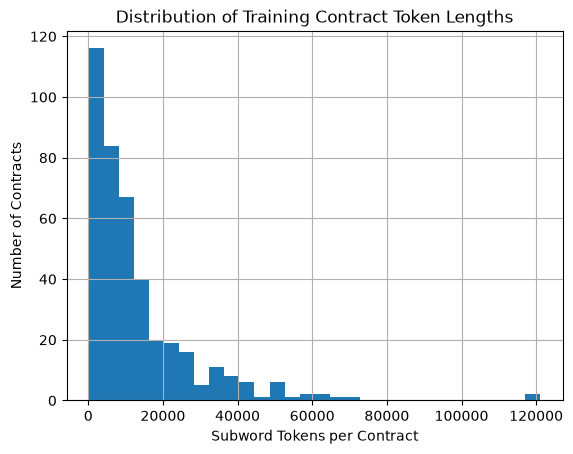

In [48]:
train_stats_df["num_tokens"].hist(bins=30)
plt.xlabel("Subword Tokens per Contract")
plt.ylabel("Number of Contracts")
plt.title("Distribution of Training Contract Token Lengths")
plt.show()

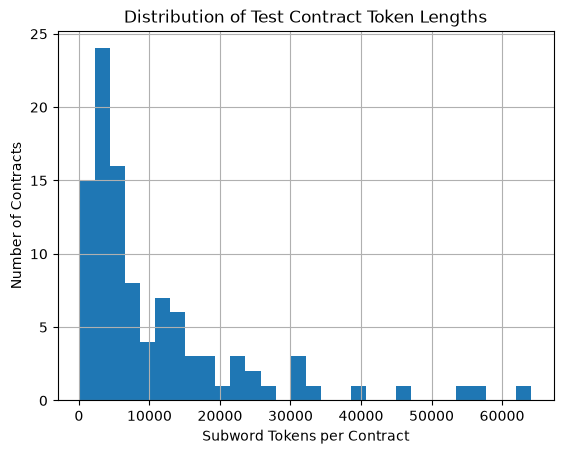

In [49]:
test_stats_df["num_tokens"].hist(bins=30)
plt.xlabel("Subword Tokens per Contract")
plt.ylabel("Number of Contracts")
plt.title("Distribution of Test Contract Token Lengths")
plt.show()

While tokenizing, we used a window size of 512 tokens because that is the maximum input size for roberta-base. The token-length statistics show that the contracts contain far more than 512 tokens on average. The training contracts contain an average of approximately 13,208 subword tokens, with a maximum of 121,051 tokens. Therefore, the contracts cannot be processed as single sequences and must be split into smaller chunks.

Looking at the graphs above, both distributions are strongly right-skewed. Even contracts on the lower end often contain thousands of subword tokens, while RoBERTa can only accept 512 tokens at a time. The training contracts required an average of approximately 35 chunks per contract, with the longest contract requiring 317 chunks.

So we split the tokenized contracts into overlapping windows of up to 512 tokens each.

We use a 128-token overlap so that clauses or answer spans near chunk boundaries retain context in the following chunk. This helps preserve context while still moving efficiently through long contracts. With a 128-token overlap, each new chunk advances by roughly 384 tokens, which limits the amount of duplicated text while maintaining context between consecutive chunks.